# Phase 3 — API Inference
Demonstrates the FastAPI prediction service: single-flow and batch prediction,
model metadata, and a live accuracy evaluation against the held-out test set.

> **Requires the API to be running:** `uvicorn api.main:app --port 8000`


In [1]:
import json
import pickle
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE = 'http://localhost:8000'
PROC = Path('../data/processed')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

def get(path):
    with urllib.request.urlopen(f'{BASE}{path}') as r:
        return json.loads(r.read())

def post(path, data):
    body = json.dumps(data).encode()
    req  = urllib.request.Request(f'{BASE}{path}', data=body,
                                   headers={'Content-Type': 'application/json'})
    with urllib.request.urlopen(req) as r:
        return json.loads(r.read())

# Verify API is up
print(get('/health'))

{'status': 'ok'}


## 1  Model info

In [2]:
info = get('/model/info')
print(f"Binary model  : {info['binary_model']}")
print(f"Multi model   : {info['multi_model']}")
print(f"Features      : {info['n_features']}")
print(f"Classes ({info['n_classes']})  : {info['classes']}")
print(f"AE threshold  : {info['anomaly_threshold']}")
print(f"Device        : {info['device']}")

Binary model  : XGBClassifier
Multi model   : XGBClassifier
Features      : 47
Classes (13)  : ['BENIGN', 'Bot', 'DDoS', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
AE threshold  : 1.4834229946136475
Device        : mps


## 2  Load test data

In [3]:
X_test = np.load(PROC / 'X_test.npy')
y_test = np.load(PROC / 'y_test_binary.npy')
y_test_multi = np.load(PROC / 'y_test_multi.npy')

with open(PROC / 'feature_cols.pkl', 'rb') as f:
    cols = pickle.load(f)
with open(PROC / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(PROC / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
with open(PROC / 'multi_class_names.pkl', 'rb') as f:
    multi_class_names = pickle.load(f)

# Inverse-transform to raw feature space (what the API expects)
X_raw = scaler.inverse_transform(X_test)
print(f'Test flows: {len(X_raw):,}  |  Features: {X_raw.shape[1]}')

Test flows: 504,160  |  Features: 47


## 3  Single-flow predictions

In [4]:
benign_idx = int(next(i for i, y in enumerate(y_test) if y == 0))
attack_idx = int(next(i for i, y in enumerate(y_test) if y == 1))

r_benign = post('/predict', {'features': dict(zip(cols, X_raw[benign_idx].tolist()))})
r_attack = post('/predict', {'features': dict(zip(cols, X_raw[attack_idx].tolist()))})

print('Benign flow prediction:')
for k, v in r_benign.items(): print(f'  {k:<20} {v}')
print()
print('Attack flow prediction:')
for k, v in r_attack.items(): print(f'  {k:<20} {v}')

Benign flow prediction:
  label                BENIGN
  is_attack            False
  confidence           0.9994
  anomaly_score        5.253315
  is_anomaly           True
  anomaly_threshold    1.483423

Attack flow prediction:
  label                DoS Hulk
  is_attack            True
  confidence           1.0
  anomaly_score        0.737048
  is_anomaly           False
  anomaly_threshold    1.483423


## 4  Batch prediction & live accuracy evaluation
Sample 2,000 flows (stratified by class) and evaluate both pipelines via the API.

In [5]:
from sklearn.utils import resample

N_SAMPLE = 2000
idx = resample(np.arange(len(X_raw)), n_samples=N_SAMPLE,
               stratify=y_test, random_state=42)
X_sample = X_raw[idx]
y_sample = y_test[idx]

flows = [dict(zip(cols, X_sample[i].tolist())) for i in range(N_SAMPLE)]

t0 = time.time()
resp = post('/predict/batch', {'flows': flows})
elapsed = time.time() - t0

results = resp['results']
print(f'Batch of {N_SAMPLE} flows predicted in {elapsed:.2f}s  ({N_SAMPLE/elapsed:.0f} flows/s)')

Batch of 2000 flows predicted in 14.01s  (143 flows/s)


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_bin   = np.array([int(r['is_attack'])  for r in results])
y_pred_anom  = np.array([int(r['is_anomaly']) for r in results])
labels_pred  = [r['label'] for r in results]

print('=== Supervised binary classifier ===')
print(classification_report(y_sample, y_pred_bin, target_names=['BENIGN', 'ATTACK']))

print('=== Autoencoder anomaly detection ===')
print(classification_report(y_sample, y_pred_anom, target_names=['BENIGN', 'ANOMALY']))

=== Supervised binary classifier ===
              precision    recall  f1-score   support

      BENIGN       0.98      1.00      0.99      1337
      ATTACK       1.00      0.97      0.98       663

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.99      2000
weighted avg       0.99      0.99      0.99      2000

=== Autoencoder anomaly detection ===
              precision    recall  f1-score   support

      BENIGN       0.93      0.93      0.93      1337
     ANOMALY       0.86      0.85      0.86       663

    accuracy                           0.91      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.91      0.91      0.91      2000



## 5  Prediction distribution & confidence

/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_84426/1608059056.py:31: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()


/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_84426/1608059056.py:32: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig('../data/processed/api_inference_summary.png', bbox_inches='tight')


/Users/apple/Desktop/NetGuardAI/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


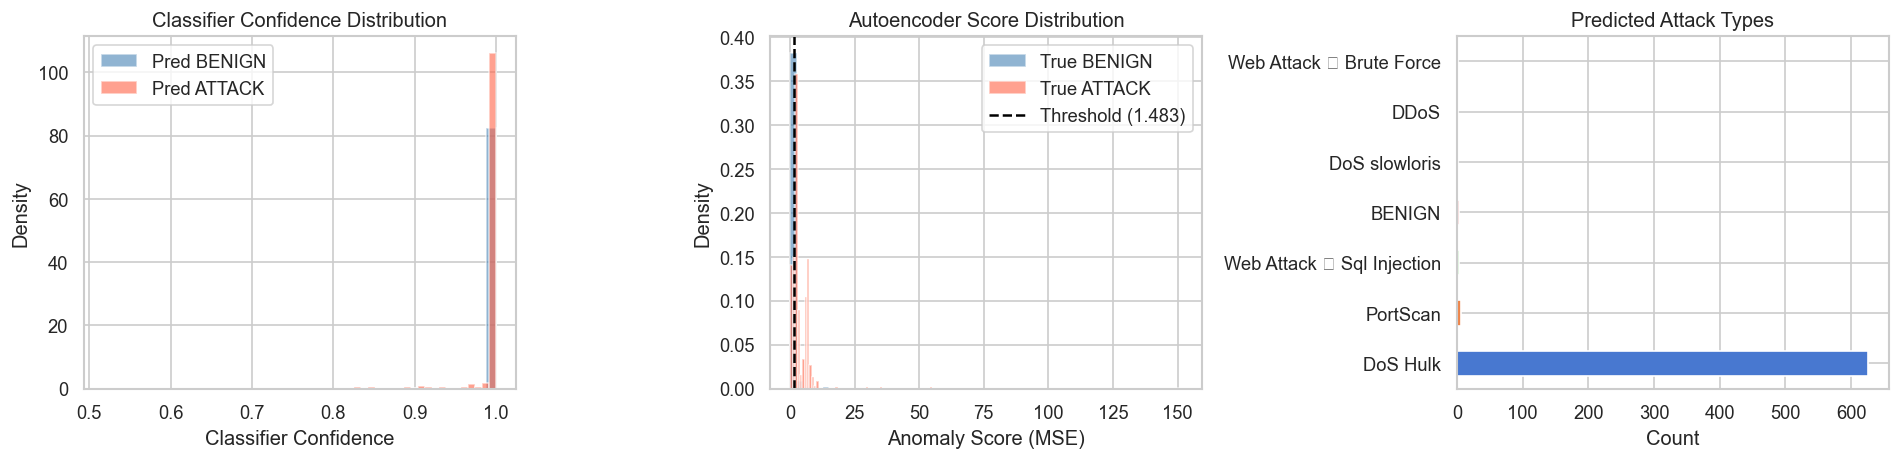

In [7]:
conf    = np.array([r['confidence']    for r in results])
scores  = np.array([r['anomaly_score'] for r in results])
threshold = results[0]['anomaly_threshold']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confidence distribution
axes[0].hist(conf[y_pred_bin == 0], bins=40, alpha=0.6, label='Pred BENIGN',  color='steelblue', density=True)
axes[0].hist(conf[y_pred_bin == 1], bins=40, alpha=0.6, label='Pred ATTACK',  color='tomato',    density=True)
axes[0].set(xlabel='Classifier Confidence', ylabel='Density',
            title='Classifier Confidence Distribution')
axes[0].legend()

# Anomaly score distribution
axes[1].hist(scores[y_sample == 0], bins=60, alpha=0.6, label='True BENIGN',  color='steelblue', density=True)
axes[1].hist(scores[y_sample == 1], bins=60, alpha=0.6, label='True ATTACK',  color='tomato',    density=True)
axes[1].axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.3f})')
axes[1].set(xlabel='Anomaly Score (MSE)', ylabel='Density',
            title='Autoencoder Score Distribution')
axes[1].legend()

# Attack type breakdown
attack_labels = pd.Series([r['label'] for r in results if r['is_attack']]).value_counts()
if not attack_labels.empty:
    attack_labels.plot(kind='barh', ax=axes[2], color=sns.color_palette('muted', len(attack_labels)))
    axes[2].set(xlabel='Count', title='Predicted Attack Types')
else:
    axes[2].text(0.5, 0.5, 'No attacks predicted', ha='center', va='center')
    axes[2].set_title('Predicted Attack Types')

plt.tight_layout()
plt.savefig('../data/processed/api_inference_summary.png', bbox_inches='tight')
plt.show()

## 6  Confusion matrix — supervised binary

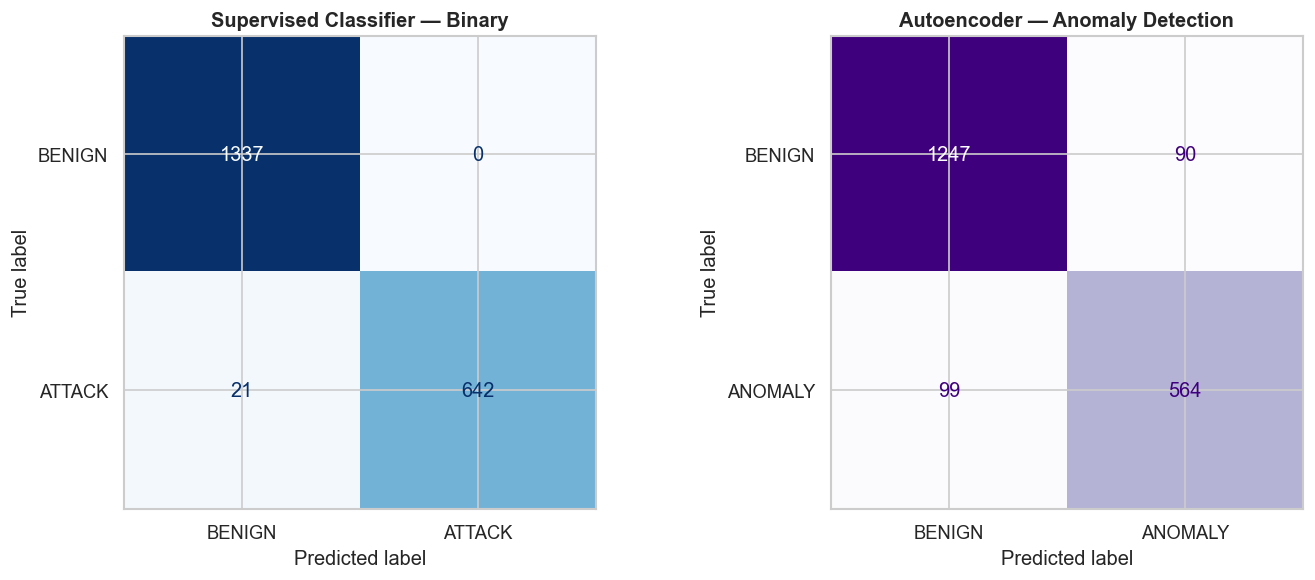

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_sample, y_pred_bin, labels=[0, 1])
ConfusionMatrixDisplay(cm1, display_labels=['BENIGN', 'ATTACK']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Supervised Classifier — Binary', fontweight='bold')

cm2 = confusion_matrix(y_sample, y_pred_anom, labels=[0, 1])
ConfusionMatrixDisplay(cm2, display_labels=['BENIGN', 'ANOMALY']).plot(
    ax=axes[1], colorbar=False, cmap='Purples'
)
axes[1].set_title('Autoencoder — Anomaly Detection', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/api_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7  Dual-pipeline agreement
Cases where the two pipelines agree vs. disagree — useful for tuning the anomaly threshold.

In [9]:
sup_attack  = y_pred_bin  == 1
ae_anomaly  = y_pred_anom == 1
true_attack = y_sample    == 1

summary = pd.DataFrame({
    'Supervised=Attack & AE=Anomaly':  (sup_attack  &  ae_anomaly).sum(),
    'Supervised=Attack & AE=Normal':   (sup_attack  & ~ae_anomaly).sum(),
    'Supervised=Benign & AE=Anomaly':  (~sup_attack &  ae_anomaly).sum(),
    'Supervised=Benign & AE=Normal':   (~sup_attack & ~ae_anomaly).sum(),
}, index=['Count']).T

summary['True attacks in group'] = [
    (true_attack &  sup_attack &  ae_anomaly).sum(),
    (true_attack &  sup_attack & ~ae_anomaly).sum(),
    (true_attack & ~sup_attack &  ae_anomaly).sum(),
    (true_attack & ~sup_attack & ~ae_anomaly).sum(),
]
summary['% of group that are attacks'] = (
    summary['True attacks in group'] / summary['Count'] * 100
).round(1)

display(summary)

,Count,True attacks in group,% of group that are attacks
Supervised=Attack & AE=Anomaly,550,550,100.0
Supervised=Attack & AE=Normal,92,92,100.0
Supervised=Benign & AE=Anomaly,104,14,13.5
Supervised=Benign & AE=Normal,1254,7,0.6
